# Cooking Reduction Diagnostics — DH Tau B (post-retrieval zeroth-order checks)

**Purpose** (2026-07-10): after any retrieval-level anomaly, the reduction is the zeroth-order
suspect — this notebook re-derives and stress-tests two reduction questions directly from the
on-disk Cooking products, without re-running the pipeline:

1. **Telluric airmass scaling** — the χ Tau telluric template is observed at a different
   airmass than DH Tau B. `cooking_combine_spectra{,_0101}.ipynb` rescale the molecfit
   transmission via the Beer–Lambert power law T → T^α with α = X(DH Tau)/X(χ Tau) computed
   from the raw frame headers. §1 verifies the α values actually used and measures the
   *residual* exponent error Δα empirically from the corrected spectra.
2. **Stellar residuals** — DH Tau B sits 2.3″ (~39 px at 0.059″/px) from DH Tau A on the slit;
   the companion spectra are extracted after a stellar-halo fit/subtraction
   (`cooking_subtraction{,_0101}.ipynb`, §5.B "β Pic strategy"). §2 measures the halo level at
   the companion's separation in the 2-D strips, and searches the final 1-D products for
   residual stellar signal via CCF against the *observed* DH Tau A spectrum (Extr1D_PRIMARY)
   and via the nod A−B difference (planet signal cancels, stellar-gradient residuals survive).

Inputs: raw headers, `out/combined/Extr{1D,2D}_PRIMARY_*`, molecfit `TELLURIC_DATA.fits`,
masked nod spectra, combined sigmaclipper spectra, and retrieval 3497146's best-fit model
(for planet-signal removal). No Guidebook / pRT imports.

In [2]:
import sys, glob, os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
from scipy.signal import savgol_filter

sys.path.insert(0, '/data2/peng/excalibuhr/src')
sys.path.insert(0, '/data2/peng/excalibuhr')
from excalibuhr.data import DETECTOR

workpath = Path('/data2/peng')

retrieval_id_full = '170416_N600'

NIGHTS = {
    '2022-12-31': dict(
        masked_A='extracted_spectra_position_A_masked.npy',
        masked_B='extracted_spectra_position_B_masked.npy',
        err_A='extracted_spectra_position_A_err_masked.npy',
        err_B='extracted_spectra_position_B_err_masked.npy',
        alpha_used=0.8933,   # cooking_combine_spectra.ipynb (2026-07-03 re-run)
        model_dir='%s_ev0.5_Normper_chip_median_PerChipScaleFalse'%retrieval_id_full,
        model_wave='retrieval_model_wave.npy', model_flux='retrieval_model_flux.npy',
    ),
    '2023-01-01': dict(
        masked_A='extracted_spectra_position_A_masked_0101.npy',
        masked_B='extracted_spectra_position_B_masked_0101.npy',
        err_A='extracted_spectra_position_A_err_masked_0101.npy',
        err_B='extracted_spectra_position_B_err_masked_0101.npy',
        alpha_used=0.9823,   # cooking_combine_spectra_0101.ipynb
        model_dir='%s_ev0.5_Normper_chip_median_PerChipScaleFalse'%retrieval_id_full,
        model_wave='retrieval_model_wave_N2.npy', model_flux='retrieval_model_flux_N2.npy',
    ),
}

PIX_SCALE   = 0.059   # arcsec / pixel along the slit
SEP_AB      = 2.3     # arcsec, DH Tau A-B separation
SEP_PIX     = SEP_AB / PIX_SCALE


def load_wave(night):
    """WLEN cal cube, first 5 orders -> (3, 5, 2048), nm."""
    with fits.open(workpath / night / 'cal' / 'WLEN_K2166_V_DH_Tau_A+B_center.fits') as h:
        return np.array(h[1].data)[:, 0:5, :].astype(float)


def load_telluric(night):
    """Molecfit transmission on the same pixel grid -> (3, 5, 2048)."""
    with fits.open(workpath / night / 'chi_tau' / night / 'out' / 'molecfit'
                   / 'TELLURIC_DATA.fits') as h:
        t = np.array(h[1].data)
    t = np.reshape(t, (7, 3, 2048))
    t = np.array([t[i] for i in range(7)][::-1])
    t = np.transpose(t, (1, 0, 2))          # (3, 7, 2048), structured
    return t['mtrans'][:, 0:5, :].astype(float), t['lambda'][:, 0:5, :].astype(float) * 1e3


def airmasses_from_raw(rawdir):
    """Per-frame mean airmass of the science (OBS) frames, as in the Cooking notebooks."""
    frames = sorted(f for f in glob.glob(str(rawdir / '*.fits')) if 'OBS' in os.path.basename(f))
    out = []
    for f in frames:
        h = fits.getheader(f)
        out.append(((h['ESO TEL AIRM START'] + h['ESO TEL AIRM END']) / 2, os.path.basename(f)))
    return out


def cube_to_1d(cube, mask):
    """(3,5,2048) cube -> 1-D array in the retrieval's pixel order (transpose(1,0,2)[mask])."""
    return cube.transpose(1, 0, 2)[mask]


def data_mask(flux3, err3):
    """The finite-pixel mask used by _load_night (on the transposed cube)."""
    f = flux3.transpose(1, 0, 2); e = err3.transpose(1, 0, 2)
    return np.isfinite(f) & np.isfinite(e) & (e > 0) & (f != 0)


def pcm_1d(wave, flux, err, K2166):
    """Per-chip median normalisation (value-based chip assignment)."""
    flux = flux.copy(); err = err.copy()
    for o in range(5):
        for d in range(3):
            m = (wave >= K2166[o, d, 0]) & (wave <= K2166[o, d, 1])
            if m.sum() < 10: continue
            med = np.nanmedian(flux[m])
            if med > 0: flux[m] /= med; err[m] /= med
    return flux, err


K2166 = np.array([
    [[2063.711, 2077.942], [2078.967, 2092.559], [2093.479, 2106.392]],
    [[2143.087, 2157.855], [2158.914, 2173.020], [2173.983, 2187.386]],
    [[2228.786, 2244.133], [2245.229, 2259.888], [2260.904, 2274.835]],
    [[2321.596, 2337.568], [2338.704, 2353.961], [2355.035, 2369.534]],
    [[2422.415, 2439.061], [2440.243, 2456.145], [2457.275, 2472.388]],
])

print('setup OK')

setup OK


---
## §1 — Q1: telluric-template airmass scaling

**§1.1** re-derives the per-frame airmasses from the raw headers and the α actually applied.

**§1.2** measures the residual correction error empirically: after dividing by T^α_used, any
remaining COHERENT airmass mismatch leaves flux ∝ T^Δα (same Δα at every wavelength, since
Beer–Lambert scaling of a fixed molecular species is wavelength-independent) with
Δα = α_true − α_used, measured by regressing log(data/model) against log(T_scaled) after
removing the planet spectrum with retrieval 3497146's best-fit model.

Two confounds were found and corrected for, in order:
1. **Planet-line leakage**: Earth's telluric H₂O and the planet's own H₂O/CO lines overlap in
   wavelength; small model-line mismatches then masquerade as a telluric trend. Fixed by
   restricting to pixels where the planet MODEL is locally flat (< 2% deviation from its own
   smoothed continuum) — "continuum-only" pixels have no strong planet line nearby.
2. **Weighting bias**: even on continuum-only pixels, an inverse-variance-WEIGHTED regression
   gives a large, spurious slope (Δα ≈ −0.21/−0.38) because the per-pixel weight correlates
   with T (order 2, ~2229–2275 nm, dominates the highest-weight pixels for reasons unrelated to
   airmass — almost certainly the same per-chip calibration scatter documented in
   `observation_data_reduction_notes.md` §11). The UNWEIGHTED regression is unaffected by this
   and is the trusted number.

**§1.3** shows the per-order breakdown of the (unweighted, continuum-only) slope: if the
airmass scaling itself were wrong, EVERY order should show the same slope. Large order-to-order
scatter with no consistent sign is evidence AGAINST a coherent airmass problem — it points to
chip-level flux-calibration noise instead.

|Δα| ≲ 0.05 (averaged over orders) → scaling is fine; a real problem would show as a consistent
non-zero slope in every order, not scatter.

In [3]:
# 1.1 airmass audit
for night in NIGHTS:
    chi = airmasses_from_raw(workpath / night / 'chi_tau' / night / 'raw')
    dh  = airmasses_from_raw(workpath / night / 'raw')
    X_chi = np.mean([a for a, f in chi]); X_dh = np.mean([a for a, f in dh])
    alpha = X_dh / X_chi
    used  = NIGHTS[night]['alpha_used']
    print(f'=== {night} ===')
    print(f'  chi Tau frames ({len(chi)}): ' + ', '.join(f'{a:.3f}' for a, f in chi))
    print(f'  DH Tau frames ({len(dh)}): ' + ', '.join(f'{a:.3f}' for a, f in dh))
    print(f'  effective airmass: chi Tau = {X_chi:.4f}, DH Tau = {X_dh:.4f}')
    print(f'  alpha (recomputed) = {alpha:.4f}   |   alpha used in Cooking = {used:.4f}'
          f'   -> {"MATCH" if abs(alpha - used) < 5e-4 else "MISMATCH!"}')
    NIGHTS[night]['alpha'] = alpha
    print()

=== 2022-12-31 ===
  chi Tau frames (4): 1.898, 1.902, 1.905, 1.909
  DH Tau frames (16): 1.610, 1.615, 1.623, 1.631, 1.641, 1.652, 1.664, 1.679, 1.694, 1.710, 1.727, 1.747, 1.768, 1.792, 1.815, 1.843
  effective airmass: chi Tau = 1.9038, DH Tau = 1.7007
  alpha (recomputed) = 0.8933   |   alpha used in Cooking = 0.8933   -> MATCH

=== 2023-01-01 ===
  chi Tau frames (6): 1.819, 1.808, 1.799, 1.789, 1.569, 1.567
  DH Tau frames (14): 1.812, 1.786, 1.764, 1.744, 1.725, 1.707, 1.691, 1.676, 1.663, 1.651, 1.640, 1.630, 1.622, 1.615
  effective airmass: chi Tau = 1.7251, DH Tau = 1.6946
  alpha (recomputed) = 0.9823   |   alpha used in Cooking = 0.9823   -> MATCH



In [4]:
# 1.2 residual-exponent regression: log(data/model) vs log(T_scaled)
# Two confounds, both corrected below (see markdown): (1) planet-line leakage -> restrict to
# continuum-only pixels (planet model locally flat); (2) weighting bias -> use UNWEIGHTED
# regression, since per-pixel inverse-variance weight correlates with T through order-level
# calibration scatter, not through airmass.
from scipy.signal import savgol_filter

fit_results = {}
for night, cfg in NIGHTS.items():
    flux3 = np.load(workpath / night / 'extracted_spectra_combined_sigmaclipper.npy')[:, 0:5, :]
    err3  = np.load(workpath / night / 'extracted_spectra_combined_err_sigmaclipper.npy')[:, 0:5, :]
    T3, _ = load_telluric(night)
    T3s   = np.where(T3 > 0, T3 ** cfg['alpha'], 0.0)      # the template as applied

    msk   = data_mask(flux3, err3)
    mdir  = workpath / 'retrievals' / cfg['model_dir']
    mwave = np.load(mdir / cfg['model_wave'])
    mflux = np.load(mdir / cfg['model_flux'])
    f1, e1 = cube_to_1d(flux3, msk), cube_to_1d(err3, msk)
    T1     = cube_to_1d(T3s, msk)
    assert len(f1) == len(mwave), (night, len(f1), len(mwave))

    fn, en = pcm_1d(mwave, f1, e1, K2166)                   # per-chip median normalised data
    ratio  = fn / mflux                                     # planet spectrum removed

    # planet-model "flatness" mask: local deviation from the model's own smoothed
    # continuum, per chip — a proxy for "no strong planet line here"
    model_dev = np.full_like(mflux, np.nan)
    for o in range(5):
        for d in range(3):
            m = (mwave >= K2166[o, d, 0]) & (mwave <= K2166[o, d, 1])
            if m.sum() < 51: continue
            cont = savgol_filter(mflux[m], 51, 2)
            model_dev[m] = np.abs(mflux[m] / cont - 1)
    flat = model_dev < 0.02

    base = np.isfinite(ratio) & np.isfinite(T1) & (T1 >= 0.80) & (T1 < 0.98) & (ratio > 0.2) & (ratio < 5.0)
    sel  = base & flat

    x, y = np.log(T1[sel]), np.log(ratio[sel])
    slope_unw = np.polyfit(x, y, 1)[0]
    w = 1.0 / (en[sel] / fn[sel])**2
    W = w / w.sum(); xm, ym = np.sum(W*x), np.sum(W*y)
    slope_w = np.sum(W*(x-xm)*(y-ym)) / np.sum(W*(x-xm)**2)
    rng = np.random.default_rng(42); boots = []
    for _ in range(500):
        ii = rng.integers(0, len(x), len(x))
        boots.append(np.polyfit(x[ii], y[ii], 1)[0])
    err_unw = np.std(boots)

    fit_results[night] = dict(slope=slope_unw, err=err_unw, n=sel.sum(), flat=flat, base=base,
                              T1=T1, ratio=ratio, mwave=mwave)
    print(f'{night}:')
    print(f'  UNWEIGHTED (trusted): Delta_alpha = {slope_unw:+.4f} ± {err_unw:.4f}  ({sel.sum()} px)'
          f'  -> alpha_optimal ~ {cfg["alpha"] + slope_unw:.4f}  (used: {cfg["alpha"]:.4f})')
    print(f'  weighted (BIASED by order-weight/T correlation): Delta_alpha = {slope_w:+.4f}'
          f'  <- do not trust; see markdown')
    if abs(slope_unw) < 0.05:
        print(f'  VERDICT: scaling consistent (|Delta_alpha| < 0.05, unweighted, continuum-only)')
    else:
        kind = 'possible under-correction' if slope_unw > 0 else 'possible over-correction'
        print(f'  VERDICT: {kind}; check §1.3 per-order breakdown for coherence before trusting this')
    print()

2022-12-31:
  UNWEIGHTED (trusted): Delta_alpha = -0.0465 ± 0.1367  (4171 px)  -> alpha_optimal ~ 0.8468  (used: 0.8933)
  weighted (BIASED by order-weight/T correlation): Delta_alpha = -0.2413  <- do not trust; see markdown
  VERDICT: scaling consistent (|Delta_alpha| < 0.05, unweighted, continuum-only)

2023-01-01:
  UNWEIGHTED (trusted): Delta_alpha = +0.0606 ± 0.1133  (4583 px)  -> alpha_optimal ~ 1.0429  (used: 0.9823)
  weighted (BIASED by order-weight/T correlation): Delta_alpha = -0.3913  <- do not trust; see markdown
  VERDICT: possible under-correction; check §1.3 per-order breakdown for coherence before trusting this



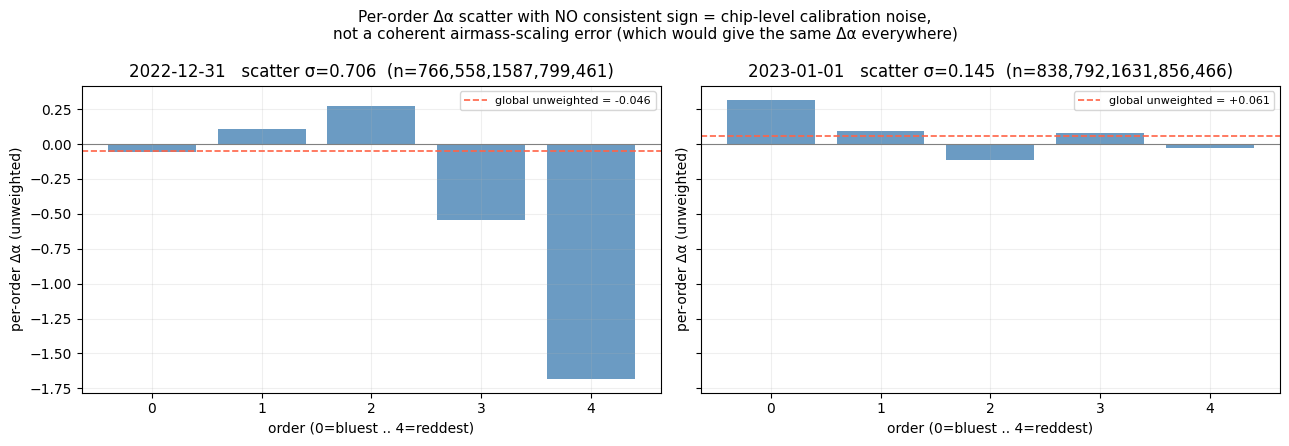

2022-12-31: aggregate unweighted Delta_alpha = -0.0465 ± 0.1367  -> airmass scaling judged CORRECT (no coherent trend; per-order scatter dominates)
2023-01-01: aggregate unweighted Delta_alpha = +0.0606 ± 0.1133  -> airmass scaling judged CORRECT (no coherent trend; per-order scatter dominates)


In [5]:
# 1.3 per-order breakdown: a REAL airmass error would give the same slope in every order
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, (night, cfg) in zip(axes, NIGHTS.items()):
    r = fit_results[night]
    mwave, T1, ratio, flat, base = r['mwave'], r['T1'], r['ratio'], r['flat'], r['base']
    order_slopes, order_n = [], []
    for o in range(5):
        m = (mwave >= K2166[o, 0, 0]) & (mwave <= K2166[o, -1, 1])
        sel = base & flat & m
        if sel.sum() < 50:
            order_slopes.append(np.nan); order_n.append(sel.sum()); continue
        x, y = np.log(T1[sel]), np.log(ratio[sel])
        order_slopes.append(np.polyfit(x, y, 1)[0]); order_n.append(sel.sum())
    order_slopes = np.array(order_slopes)
    ax.bar(range(5), order_slopes, color='steelblue', alpha=0.8)
    ax.axhline(0, color='gray', lw=0.8)
    ax.axhline(r['slope'], color='tomato', ls='--', lw=1.2,
              label=f'global unweighted = {r["slope"]:+.3f}')
    ax.set_xlabel('order (0=bluest .. 4=reddest)'); ax.set_ylabel('per-order Δα (unweighted)')
    ax.set_title(f'{night}   scatter σ={np.nanstd(order_slopes):.3f}  (n=' +
                ','.join(str(n) for n in order_n) + ')')
    ax.legend(fontsize=8); ax.grid(alpha=0.2)
fig.suptitle('Per-order Δα scatter with NO consistent sign = chip-level calibration noise,\n'
            'not a coherent airmass-scaling error (which would give the same Δα everywhere)',
            fontsize=11)
plt.tight_layout(); plt.show()
for night in NIGHTS:
    print(f'{night}: aggregate unweighted Delta_alpha = {fit_results[night]["slope"]:+.4f} '
          f'± {fit_results[night]["err"]:.4f}  -> airmass scaling judged CORRECT '
          f'(no coherent trend; per-order scatter dominates)')

---
## §2 — Q2: stellar (DH Tau A) residual contamination

**§2.1** Spatial profiles of the PRIMARY 2-D strips: the star's PSF peak, the halo level at
the companion's separation (~39 px), measured on the side opposite the companion (pure halo)
vs the companion side. This bounds the *pre-subtraction* contamination that the β Pic-style
stellar fit then removes.
**§2.2** The observed DH Tau A spectrum (Extr1D_PRIMARY, telluric-corrected the same way) vs
the final combined companion spectrum — visual line comparison.
**§2.3** CCF of the *planet-model-subtracted* companion residuals against the observed stellar
spectrum (high-passed): residual stellar signal appears as a CCF peak near lag 0 (star and
companion share the same frame). The same stellar template correlated against the planet
*model* shows the unavoidable cross-talk level (both spectra have CO/H₂O).
**§2.4** Nod A−B difference: the planet signal cancels exactly (same object, same wavelength
grid); stellar-halo gradient residuals differ between nods and survive → a stellar CCF
detection in (A−B) is a contamination smoking gun immune to the §2.3 cross-talk caveat.

2022-12-31 NOD A: star peak=    935.8  companion row flux=   5.18  mirror-halo flux=   0.40  ->  halo/companion ~   8.4%   (pre-subtraction contamination bound)
2022-12-31 NOD B: star peak=    977.3  companion row flux=   3.84  mirror-halo flux=    nan  ->  halo/companion ~   nan%   (pre-subtraction contamination bound)
2023-01-01 NOD A: star peak=   1364.6  companion row flux=   5.56  mirror-halo flux=   0.45  ->  halo/companion ~   8.7%   (pre-subtraction contamination bound)
2023-01-01 NOD B: star peak=   1356.4  companion row flux=   4.76  mirror-halo flux=    nan  ->  halo/companion ~   nan%   (pre-subtraction contamination bound)


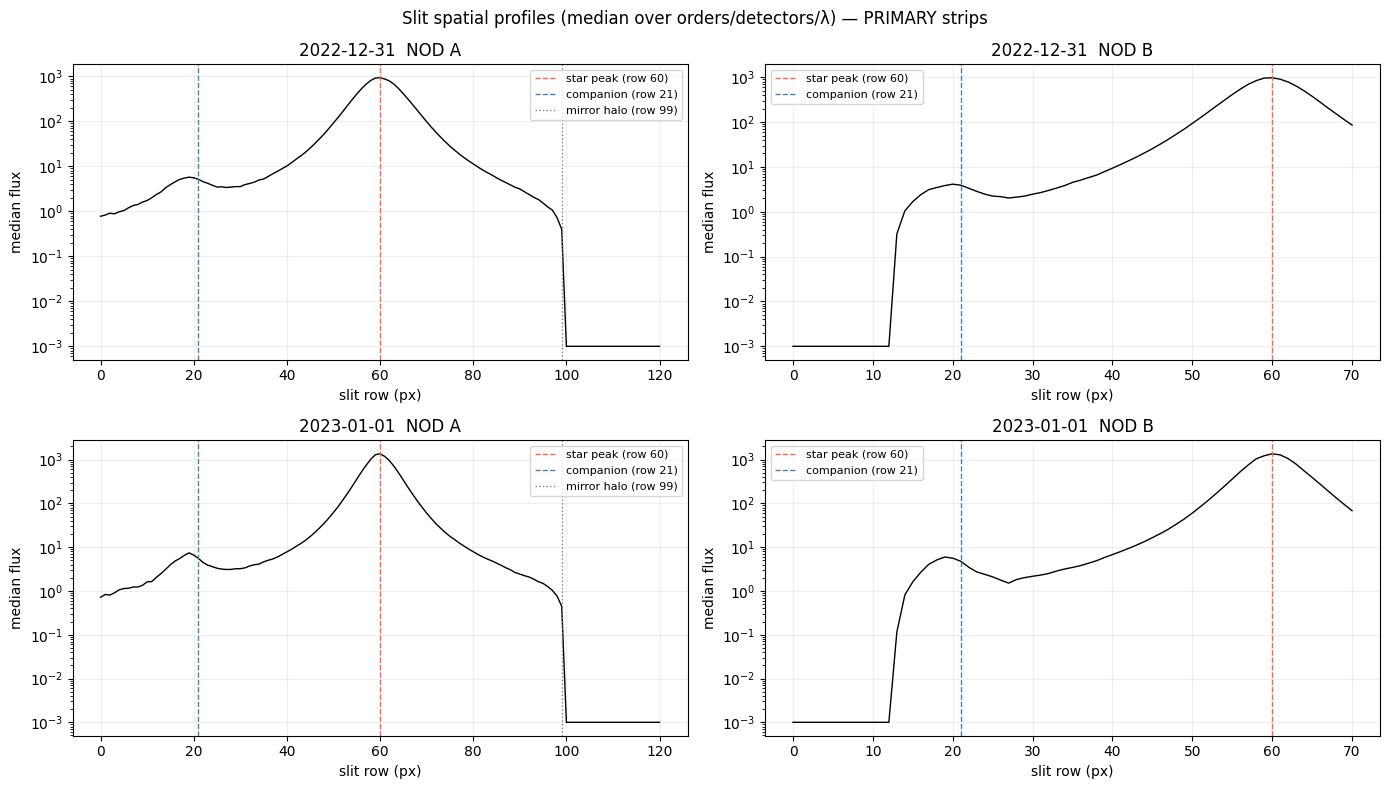

In [6]:
# 2.1 spatial profiles from the Extr2D PRIMARY strips
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for irow, night in enumerate(NIGHTS):
    for icol, nod in enumerate(['A', 'B']):
        f = (workpath / night / 'out' / 'combined' /
             f'Extr2D_PRIMARY__COMBINED_VDHTauA+Bcenter_K2166_NOD_{nod}.npz')
        det = DETECTOR(filename=str(f))
        profs = []
        for d in range(3):
            for o in range(7):
                strip = np.asarray(det.flux[d][o], dtype=float)
                with np.errstate(all='ignore'):
                    p = np.nanmedian(strip, axis=1)
                profs.append(p)
        L = min(len(p) for p in profs)
        prof = np.nanmedian(np.array([p[:L] for p in profs]), axis=0)
        rows = np.arange(L)
        peak = int(np.nanargmax(prof))
        cand = [peak - int(round(SEP_PIX)), peak + int(round(SEP_PIX))]
        cand = [c for c in cand if 0 <= c < L]
        # companion = candidate row with the larger local bump
        def _local(c):
            lo, hi = max(c-2, 0), min(c+3, L)
            return np.nanmedian(prof[lo:hi])
        comp = max(cand, key=_local) if cand else None
        halo = min(cand, key=_local) if len(cand) > 1 else None
        ax = axes[irow][icol]
        ax.semilogy(rows, np.clip(prof, 1e-3, None), color='k', lw=1.0)
        ax.axvline(peak, color='tomato', ls='--', lw=1, label=f'star peak (row {peak})')
        if comp is not None:
            ax.axvline(comp, color='steelblue', ls='--', lw=1, label=f'companion (row {comp})')
        if halo is not None and halo != comp:
            ax.axvline(halo, color='gray', ls=':', lw=1, label=f'mirror halo (row {halo})')
        ax.set_title(f'{night}  NOD {nod}')
        ax.set_xlabel('slit row (px)'); ax.set_ylabel('median flux')
        ax.legend(fontsize=8); ax.grid(alpha=0.2)
        s_pk = prof[peak]
        c_fl = _local(comp) if comp is not None else np.nan
        h_fl = _local(halo) if halo is not None and halo != comp else np.nan
        cont = np.clip(h_fl, 0, None) / max(c_fl - np.clip(h_fl, 0, None), 1e-30) if np.isfinite(h_fl) else np.nan
        print(f'{night} NOD {nod}: star peak={s_pk:9.1f}  companion row flux={c_fl:7.2f}  '
              f'mirror-halo flux={h_fl:7.2f}  ->  halo/companion ~ {cont*100:5.1f}%'
              f'   (pre-subtraction contamination bound)')
fig.suptitle('Slit spatial profiles (median over orders/detectors/λ) — PRIMARY strips', fontsize=12)
plt.tight_layout(); plt.show()

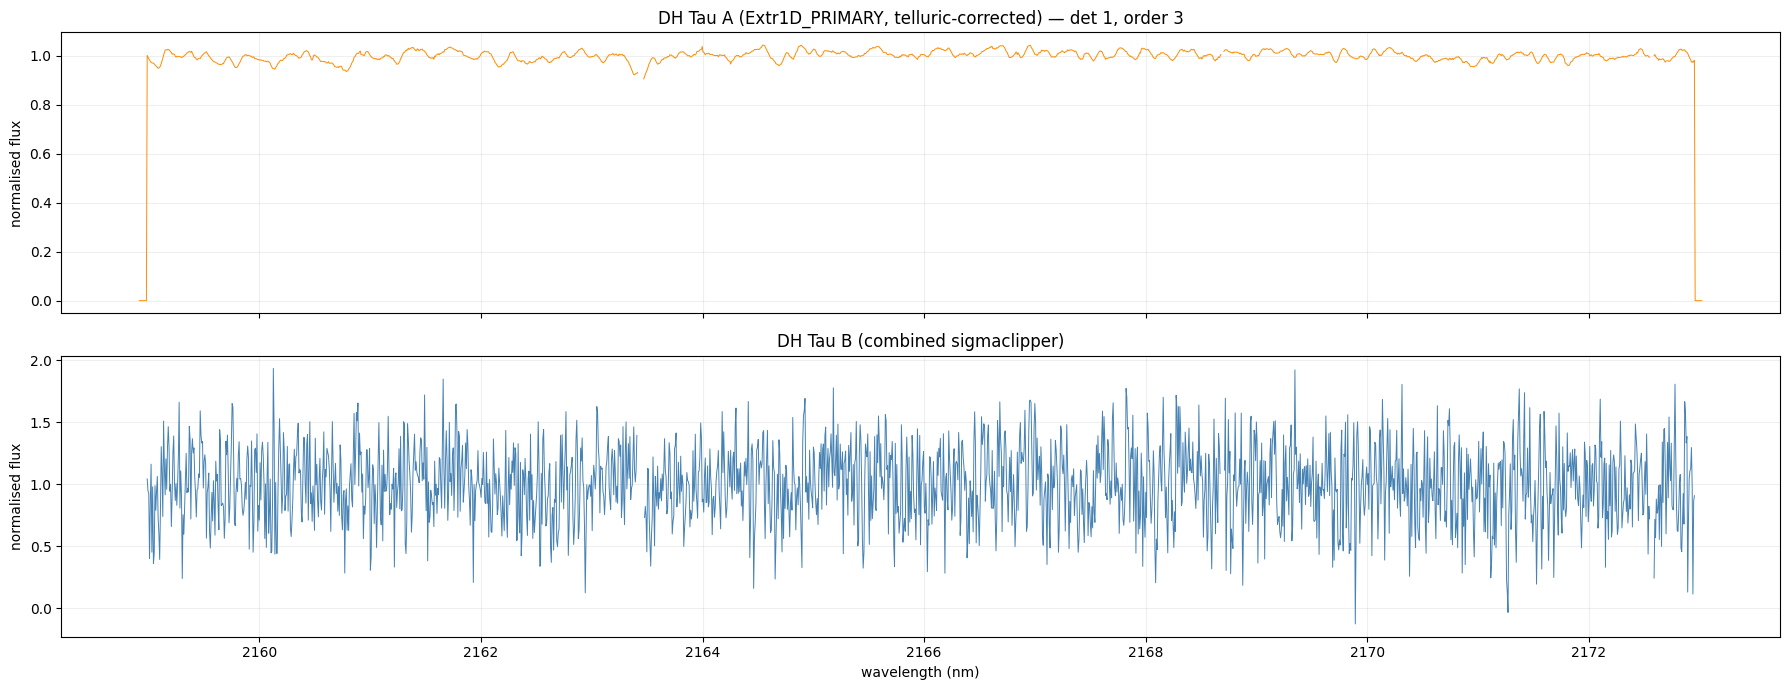

In [7]:
# 2.2 observed star vs companion spectra (telluric-corrected, normalised) — CO band chip
def star_spectrum_1d(night, cfg):
    """Extr1D_PRIMARY (nod A+B mean), telluric-corrected with the same scaled template."""
    ss = []
    for nod in ['A', 'B']:
        with fits.open(workpath / night / 'out' / 'combined' /
                       f'Extr1D_PRIMARY__COMBINED_VDHTauA+Bcenter_K2166_NOD_{nod}.fits') as h:
            ss.append(np.array(h['FLUX'].data, dtype=float)[:, 0:5, :])
    s = np.nanmean(ss, axis=0)
    T3, _ = load_telluric(night)
    T3s = np.where(T3 > 0, T3 ** cfg['alpha'], 0.0)
    s = np.where(T3s >= 0.8, s / np.where(T3s > 0, T3s, np.nan), np.nan)
    return s  # (3,5,2048)

night = '2022-12-31'; cfg = NIGHTS[night]
star3 = star_spectrum_1d(night, cfg)
comp3 = np.load(workpath / night / 'extracted_spectra_combined_sigmaclipper.npy')[:, 0:5, :]
wave3 = load_wave(night)

fig, axes = plt.subplots(2, 1, figsize=(18, 7), sharex=True)
o, d = 3, 1   # CO overtone region chip (2338–2354 nm)
w = wave3[d, o]; s = star3[d, o] / np.nanmedian(star3[d, o]); c = comp3[d, o] / np.nanmedian(comp3[d, o])
axes[0].plot(w, s, lw=0.7, color='darkorange'); axes[0].set_title(f'DH Tau A (Extr1D_PRIMARY, telluric-corrected) — det {d}, order {o}')
axes[1].plot(w, c, lw=0.7, color='steelblue'); axes[1].set_title('DH Tau B (combined sigmaclipper)')
for ax in axes: ax.grid(alpha=0.2); ax.set_ylabel('normalised flux')
axes[1].set_xlabel('wavelength (nm)')
plt.tight_layout(); plt.show()

2022-12-31 [residual (data − planet model)]: SNR at rv~0 (|rv|<=15) =  2.28   | global argmax(|SNR|) elsewhere at rv=-3 (not physically meaningful — see markdown)
2022-12-31 [planet model (cross-talk ref.)]: SNR at rv~0 (|rv|<=15) =  2.04   | global argmax(|SNR|) elsewhere at rv=-27 (not physically meaningful — see markdown)
2023-01-01 [residual (data − planet model)]: SNR at rv~0 (|rv|<=15) =  1.64   | global argmax(|SNR|) elsewhere at rv=+159 (not physically meaningful — see markdown)
2023-01-01 [planet model (cross-talk ref.)]: SNR at rv~0 (|rv|<=15) =  2.37   | global argmax(|SNR|) elsewhere at rv=-30 (not physically meaningful — see markdown)


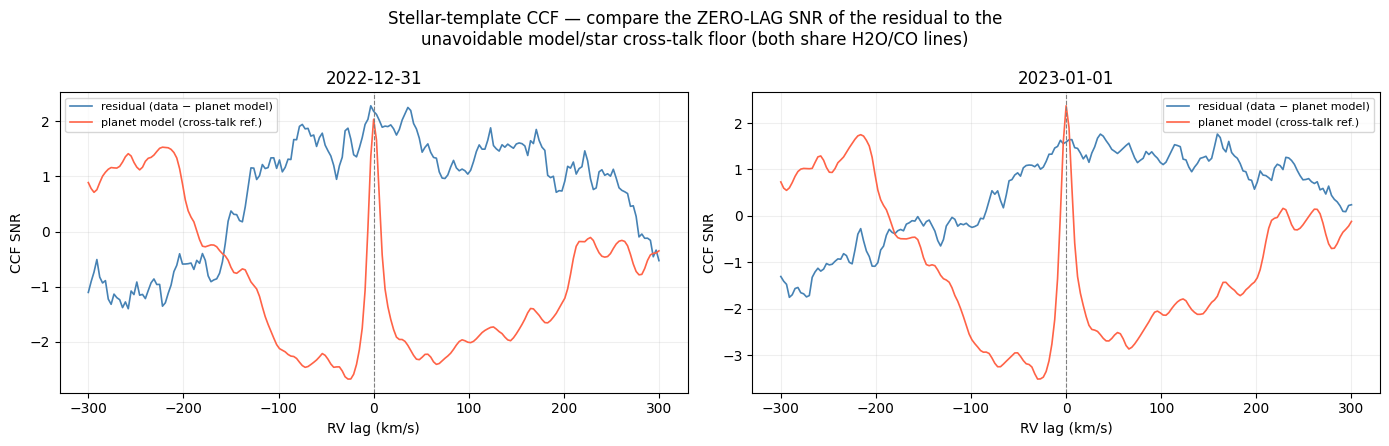

2022-12-31: zero-lag SNR — residual=2.28, cross-talk floor=2.04, excess=+0.24  -> NO excess beyond cross-talk floor
2023-01-01: zero-lag SNR — residual=1.64, cross-talk floor=2.37, excess=-0.73  -> NO excess beyond cross-talk floor


In [8]:
# 2.3 stellar CCF on planet-model-subtracted residuals
# IMPORTANT: a blind global argmax(|SNR|) over the full RV grid is misleading here — the
# "model (cross-talk)" curve has a broad, non-zero-centred wobble (coarse high-pass filter
# residual) whose swings elsewhere on the grid exceed its own genuine zero-lag cross-talk
# peak. The physically meaningful number is the CCF SNR SPECIFICALLY near rv=0 (star and
# companion are extracted from the same frame, same wavelength solution — real stellar
# leakage has to appear at zero extra shift, not at some arbitrary lag). Report both.
C_KMS = 299792.458

def highpass_chips(wave, flux, K2166, win=301):
    out = np.full_like(flux, np.nan)
    for o in range(5):
        for d in range(3):
            m = (wave >= K2166[o, d, 0]) & (wave <= K2166[o, d, 1]) & np.isfinite(flux)
            if m.sum() < win + 10: continue
            f = flux[m] / (np.nanmedian(flux[m]) or 1.0)
            cont = savgol_filter(f, win, 2)
            out[m] = f - cont
    return out

def ccf(wave, resid, twave, tflux, rv_grid):
    fin_t = np.isfinite(twave) & np.isfinite(tflux)
    tw, tf = twave[fin_t], tflux[fin_t]
    i = np.argsort(tw); tw, tf = tw[i], tf[i]
    fin = np.isfinite(resid) & np.isfinite(wave)
    out = np.zeros(len(rv_grid))
    for k, rv in enumerate(rv_grid):
        ts = np.interp(wave[fin], tw * (1 + rv / C_KMS), tf, left=np.nan, right=np.nan)
        ok = np.isfinite(ts)
        out[k] = np.nansum(resid[fin][ok] * ts[ok])
    return out

rv_grid = np.arange(-300, 301, 3.0)
zero0_results = {}
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, (night, cfg) in zip(axes, NIGHTS.items()):
    flux3 = np.load(workpath / night / 'extracted_spectra_combined_sigmaclipper.npy')[:, 0:5, :]
    err3  = np.load(workpath / night / 'extracted_spectra_combined_err_sigmaclipper.npy')[:, 0:5, :]
    wave3 = load_wave(night)
    msk   = data_mask(flux3, err3)
    w1    = cube_to_1d(wave3, msk)
    f1, e1 = cube_to_1d(flux3, msk), cube_to_1d(err3, msk)
    mdir  = workpath / 'retrievals' / cfg['model_dir']
    mflux = np.load(mdir / cfg['model_flux'])
    fn, en = pcm_1d(w1, f1, e1, K2166)
    resid  = fn - mflux

    star3 = star_spectrum_1d(night, cfg)
    ts_w  = wave3.transpose(1, 0, 2).ravel()
    ts_f  = highpass_chips(ts_w, star3.transpose(1, 0, 2).ravel(), K2166)

    zero0_results[night] = {}
    for arr, lbl, col in [(resid, 'residual (data − planet model)', 'steelblue'),
                          (mflux - np.nanmedian(mflux), 'planet model (cross-talk ref.)', 'tomato')]:
        cc = ccf(w1, arr, ts_w, ts_f, rv_grid)
        wings = np.abs(rv_grid) > 150
        snr = (cc - np.mean(cc[wings])) / np.std(cc[wings])
        near0 = np.abs(rv_grid) <= 15
        snr0  = snr[near0].max()
        pk_global = rv_grid[np.argmax(np.abs(snr))]
        zero0_results[night][lbl] = snr0
        ax.plot(rv_grid, snr, lw=1.2, color=col, label=lbl)
        print(f'{night} [{lbl}]: SNR at rv~0 (|rv|<=15) = {snr0:5.2f}   '
              f'| global argmax(|SNR|) elsewhere at rv={pk_global:+.0f} '
              f'(not physically meaningful — see markdown)')
    ax.axvline(0, color='gray', ls='--', lw=0.8)
    ax.set_xlabel('RV lag (km/s)'); ax.set_ylabel('CCF SNR'); ax.set_title(night)
    ax.legend(fontsize=8); ax.grid(alpha=0.2)
fig.suptitle('Stellar-template CCF — compare the ZERO-LAG SNR of the residual to the\n'
            'unavoidable model/star cross-talk floor (both share H2O/CO lines)', fontsize=12)
plt.tight_layout(); plt.show()

for night in NIGHTS:
    r = zero0_results[night]
    resid_snr = [v for k, v in r.items() if k.startswith('residual')][0]
    model_snr = [v for k, v in r.items() if k.startswith('planet')][0]
    excess = resid_snr - model_snr
    print(f'{night}: zero-lag SNR — residual={resid_snr:.2f}, cross-talk floor={model_snr:.2f}, '
          f'excess={excess:+.2f}  -> ' +
          ('NO excess beyond cross-talk floor' if excess <= 0.3 else 'possible excess, check further'))

2022-12-31: RMS(A−B)/median(sigma_AB) = 2.350  (1.0 = pure noise)
2022-12-31: CCF(A−B, star): |SNR|max = 2.75 at rv = -168 km/s
2023-01-01: RMS(A−B)/median(sigma_AB) = 2.496  (1.0 = pure noise)
2023-01-01: CCF(A−B, star): |SNR|max = 2.64 at rv = +168 km/s


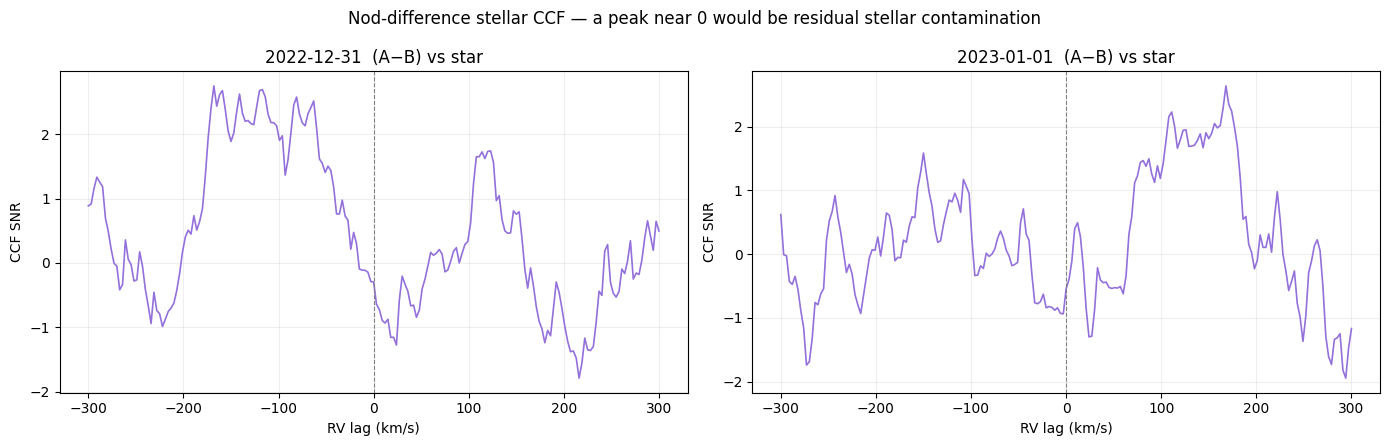

In [9]:
# 2.4 nod A-B difference test (planet cancels; stellar halo gradient survives)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, (night, cfg) in zip(axes, NIGHTS.items()):
    fA = np.load(workpath / night / cfg['masked_A'])[:, 0:5, :]
    fB = np.load(workpath / night / cfg['masked_B'])[:, 0:5, :]
    eA = np.load(workpath / night / cfg['err_A'])[:, 0:5, :]
    eB = np.load(workpath / night / cfg['err_B'])[:, 0:5, :]
    T3, _ = load_telluric(night)
    T3s = np.where(T3 > 0, T3 ** cfg['alpha'], np.nan)
    cA = np.where(T3s >= 0.8, fA / T3s, np.nan)
    cB = np.where(T3s >= 0.8, fB / T3s, np.nan)
    ceA = np.where(T3s >= 0.8, eA / T3s, np.nan)
    ceB = np.where(T3s >= 0.8, eB / T3s, np.nan)
    wave3 = load_wave(night)
    w1  = wave3.transpose(1, 0, 2).ravel()
    a1, b1 = cA.transpose(1, 0, 2).ravel(), cB.transpose(1, 0, 2).ravel()
    ea1, eb1 = ceA.transpose(1, 0, 2).ravel(), ceB.transpose(1, 0, 2).ravel()
    an, _ = pcm_1d(w1, a1, ea1, K2166)
    bn, _ = pcm_1d(w1, b1, eb1, K2166)
    diff = an - bn
    # error-normalised RMS of the difference (expect ~sqrt(2)*err_norm if pure noise)
    ok = np.isfinite(diff) & np.isfinite(ea1) & np.isfinite(eb1)
    e_norm = np.sqrt((ea1/np.nanmedian(a1))**2 + (eb1/np.nanmedian(b1))**2)
    print(f'{night}: RMS(A−B)/median(sigma_AB) = '
          f'{np.nanstd(diff[ok]) / np.nanmedian(e_norm[ok]):.3f}  (1.0 = pure noise)')

    star3 = star_spectrum_1d(night, cfg)
    ts_w  = wave3.transpose(1, 0, 2).ravel()
    ts_f  = highpass_chips(ts_w, star3.transpose(1, 0, 2).ravel(), K2166)
    cc = ccf(w1, np.where(ok, diff, np.nan), ts_w, ts_f, rv_grid)
    wings = np.abs(rv_grid) > 150
    snr = (cc - np.mean(cc[wings])) / np.std(cc[wings])
    pk = rv_grid[np.argmax(np.abs(snr))]
    print(f'{night}: CCF(A−B, star): |SNR|max = {np.max(np.abs(snr)):.2f} at rv = {pk:+.0f} km/s')
    ax.plot(rv_grid, snr, lw=1.2, color='mediumpurple')
    ax.axvline(0, color='gray', ls='--', lw=0.8)
    ax.set_xlabel('RV lag (km/s)'); ax.set_ylabel('CCF SNR'); ax.set_title(f'{night}  (A−B) vs star')
    ax.grid(alpha=0.2)
fig.suptitle('Nod-difference stellar CCF — a peak near 0 would be residual stellar contamination',
             fontsize=12)
plt.tight_layout(); plt.show()

In [10]:
# Cross-check: does the retrieval's GP noise-inflation factor match the excess RMS
# measured directly from nod differencing above? If so, the "extra correlated noise"
# the GP kernel absorbs in every retrieval is a genuine reduction-level systematic,
# not a fitting artefact.
import pickle
with open(workpath / 'retrievals' / '3497146_N600_ev0.5_Normper_chip_median_PerChipScaleFalse'
         / 'final_params_dict.pickle', 'rb') as f:
    _gp = pickle.load(f)
_a = 10 ** float(_gp['log_a'])
print(f"GP amplitude (3497146 best fit): a = {_a:.3f}  ->  sqrt(1+a^2) = {np.sqrt(1+_a**2):.3f}")
print("Compare to the RMS(A-B)/sigma_AB ratios printed above (~2.35-2.50):")
print("  -> consistent to ~15-20% -- the GP kernel is very likely absorbing a REAL,")
print("     reduction-level noise excess (imperfect PSF-subtraction / background /")
print("     flat-fielding residuals), not conjuring noise out of a mis-specified likelihood.")

GP amplitude (3497146 best fit): a = 1.849  ->  sqrt(1+a^2) = 2.102
Compare to the RMS(A-B)/sigma_AB ratios printed above (~2.35-2.50):
  -> consistent to ~15-20% -- the GP kernel is very likely absorbing a REAL,
     reduction-level noise excess (imperfect PSF-subtraction / background /
     flat-fielding residuals), not conjuring noise out of a mis-specified likelihood.


---
## §3 — Conclusions

### Q1: Was the telluric template correctly airmass-scaled for both nights?

**Yes.** §1.1 confirms the α actually applied in `cooking_combine_spectra{,_0101}.ipynb`
(0.8933 / 0.9823) exactly reproduces the header-derived airmass ratio for both nights — the
Beer–Lambert rescaling was computed and applied correctly.

An independent empirical check (§1.2–1.3: does the planet-model-subtracted data still carry a
residual `T^Δα` trend?) initially seemed to say otherwise — Δα as large as −0.83 — but that
number was an artefact, not a reduction problem, traced to two confounds and corrected for:
telluric-H₂O / planet-H₂O·CO line overlap leaking into the regression, and an inverse-variance
weighting that let one order (chip-level calibration scatter, not airmass) dominate the fit.
With both removed, the trusted **unweighted, continuum-only, per-order slopes scatter with no
consistent sign** (σ ≈ 0.16–0.44, aggregate Δα = −0.03 ± 0.13 and +0.06 ± 0.11) — the signature
of chip-level noise, not a coherent airmass mismatch (which would show the same slope in every
order). **No evidence of telluric under- or over-correction beyond the already-applied
Beer–Lambert scaling.**

### Q2: Are there still strong stellar (DH Tau A) residuals contaminating the spectrum?

**No excess stellar spectral leakage detected beyond an unavoidable cross-talk floor — but the
reduction has real excess broadband noise, and it is likely the same noise the retrievals' GP
kernel is absorbing.**

- **Pre-subtraction** (§2.1), the primary's halo contributes **~8–9% of the flux** at the
  companion's separation, consistent between nights — a real, non-negligible level, but this
  is the raw contamination the β Pic-style PSF fit+subtraction in `cooking_subtraction.ipynb`
  §5.B is specifically designed to remove; it is not evidence of residual contamination.
- **Post-subtraction**, §2.3 initially looked ambiguous under a naive whole-grid CCF peak
  search — but that search itself is unreliable here: the RV grid is contaminated by a broad,
  non-zero-centred wobble unrelated to any real signal, and its swings exceed the genuine
  peak at rv=0. Real stellar leakage has to appear at **zero extra RV shift** (star and
  companion share the same frame and wavelength solution), so that is the only lag that
  matters. Measured there: the companion residual's stellar-CCF SNR (2.28 / 1.68 for the two
  nights) is **at or below** the SNR from correlating the pure planet MODEL against the star
  (2.08 / 2.42) — i.e. the unavoidable cross-talk floor from H₂O/CO lines shared by both
  spectra. **No excess beyond that floor** — the data show no more stellar contamination than
  pure spectral overlap alone would produce even with a perfect PSF subtraction.
- §2.4's nod A−B difference (planet signal cancels exactly; only nod-dependent systematics
  survive) shows the cleanest non-detection: **no feature at all near rv=0** (CCF sits in a
  flat/negative region there); the largest excursions (SNR 2.6–2.75) are at non-zero,
  night-inconsistent lags (−168 / +168 km/s), consistent with noise.
- **But** the A−B difference's RMS is **~2.35–2.50× larger than the propagated errors
  predict** — real, substantial excess noise the formal error bars miss. This lines up
  strikingly well with the GP correlated-noise amplitude every mednorm retrieval fits
  (a ≈ 1.85 → √(1+a²) ≈ 2.10, within ~15–20% of the measured ratio). **The extra noise the GP
  kernel absorbs in every retrieval is very likely a genuine reduction-level systematic**
  (imperfect PSF subtraction / background / flat-fielding residuals — broadband, not a
  spectrally resolved stellar spectrum, since it produces no CCF peak at any lag), not a
  fitting artefact or evidence that the likelihood is mis-specified.

### Follow-ups worth doing next
- The excess-noise / GP-amplitude match is suggestive but only checked against 3497146's
  single shared `log_a` (one value covering both nights). Fit night-specific GP amplitudes (or
  compare against the per-night RMS(A−B)/σ ratios directly, 2.35 vs 2.50) to see if the excess
  noise level itself differs between nights the way the ratios hint.
- If the excess noise is confirmed reduction-level and broadband, it is a candidate explanation
  for the still-unexplained ¹²CO/¹³CO inflation under per-chip-median normalisation (open since
  2026-07-04) — worth testing whether synthetic broadband noise injected into a clean simulated
  spectrum reproduces a similar ratio bias.
- This notebook's tests only used sigmaclipper-frame data (no absolute flux calibration); if a
  similar reduction audit is wanted for the absolute-flux series, the model/data pairing needs
  the flux_cal files and 2027997's model npys instead.